In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
X = car_evaluation.data.features
y = car_evaluation.data.targets

# metadata
print(car_evaluation.metadata)

# variable information
print(car_evaluation.variables)


{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Applications, 

In [3]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# Креираме копија од X за да ги зачуваме оригиналните податоци ако ни требаат
X_processed = X.copy()

# Дефинираме точен редослед за секоја категорична колона (од најмало кон најголемо)
buying_maint_order = ['low', 'med', 'high', 'vhigh']
doors_order = ['2', '3', '4', '5more']
persons_order = ['2', '4', 'more']
lug_boot_order = ['small', 'med', 'big']
safety_order = ['low', 'med', 'high']

# Креираме OrdinalEncoder со специфицираниот редослед
encoder = OrdinalEncoder(categories=[
    buying_maint_order,  # за buying
    buying_maint_order,  # за maint
    doors_order,         # за doors
    persons_order,       # за persons
    lug_boot_order,      # за lug_boot
    safety_order         # за safety
])

# Примена на енкодирањето врз карактеристиките
X_encoded = encoder.fit_transform(X_processed)

# Претворање назад во Pandas DataFrame за подобра прегледност
X_encoded_df = pd.DataFrame(X_encoded, columns=X.columns)

print("\n--- Податоците по претпроцесирање (Енкодирани во бројки) ---")
print(X_encoded_df.head())


--- Податоците по претпроцесирање (Енкодирани во бројки) ---
   buying  maint  doors  persons  lug_boot  safety
0     3.0    3.0    0.0      0.0       0.0     0.0
1     3.0    3.0    0.0      0.0       0.0     1.0
2     3.0    3.0    0.0      0.0       0.0     2.0
3     3.0    3.0    0.0      0.0       1.0     0.0
4     3.0    3.0    0.0      0.0       1.0     1.0


Decision Tree

--- Резултати од експериментите на Decision Tree ---
Најдобри пронајдени параметри: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Најдобра точност за време на тренирање (CV score): 97.83%
Точност на тест множеството: 96.53%

Детален класификациски извештај:
              precision    recall  f1-score   support

         acc       0.97      0.90      0.94        83
        good       0.56      0.91      0.69        11
       unacc       0.99      1.00      1.00       235
       vgood       1.00      0.82      0.90        17

    accuracy                           0.97       346
   macro avg       0.88      0.91      0.88       346
weighted avg       0.97      0.97      0.97       346



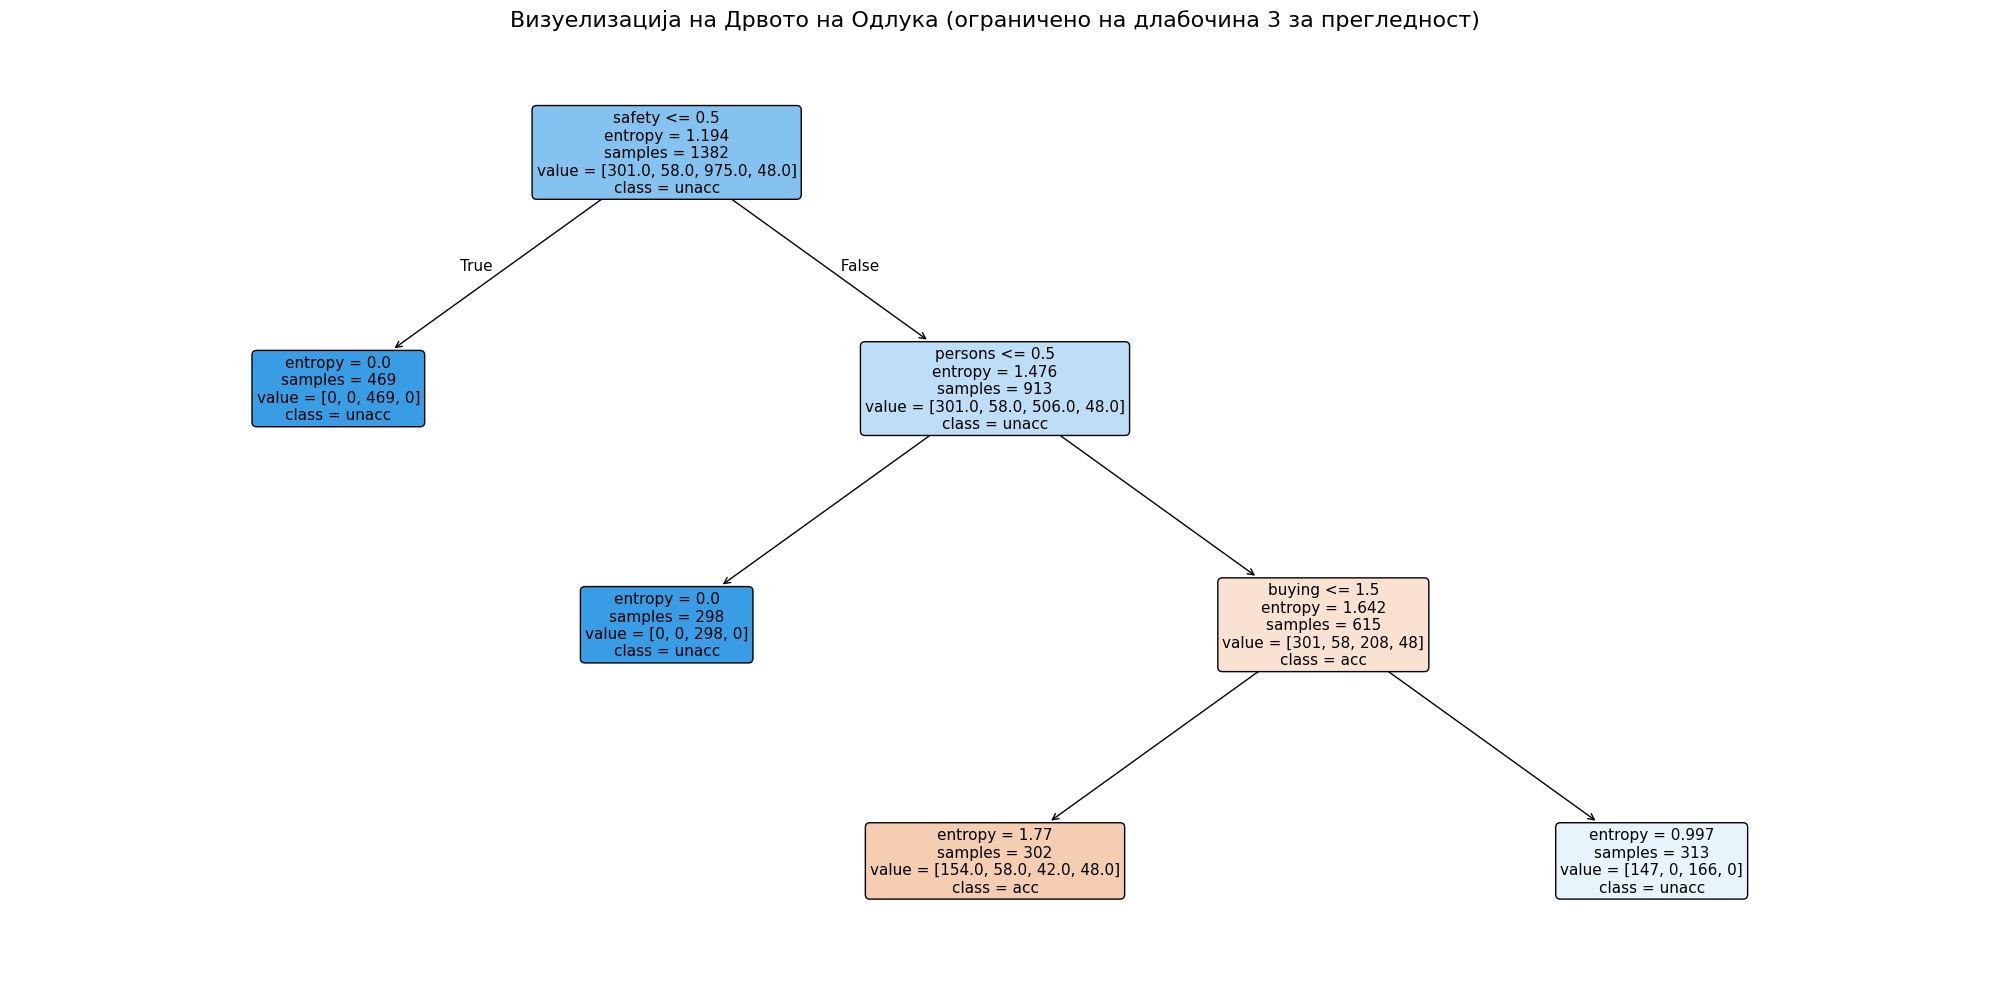


--- Рангирање на атрибутите по важност ---
 Атрибут  Важност
  safety 0.256150
 persons 0.228670
   maint 0.167394
  buying 0.162415
lug_boot 0.124997
   doors 0.060373


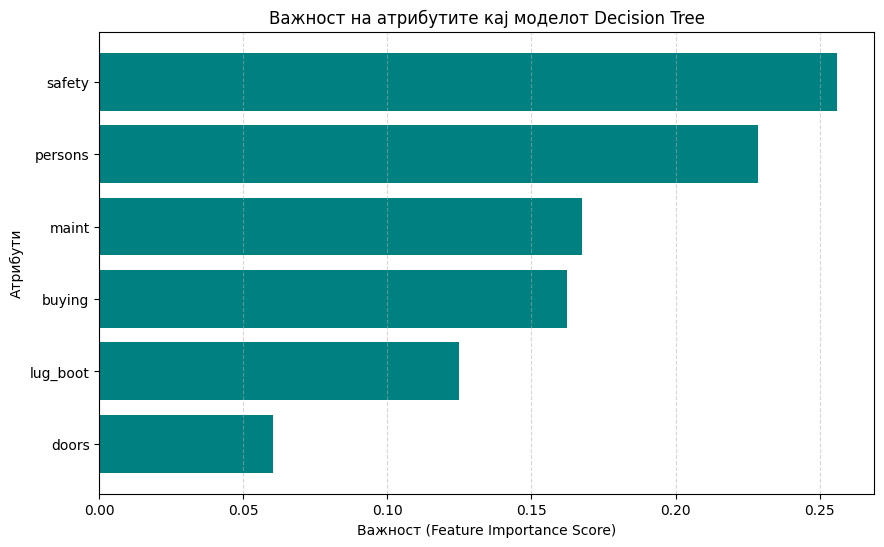

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# ==========================================================
# 1. ПОДЕЛБА НА ПОДАТОЦИТЕ (ТРЕНИРАЊЕ И ТЕСТИРАЊЕ)
# ==========================================================

# Го делиме множеството во сооднос 80% за тренирање и 20% за тестирање
# y треба да биде дефинирано претходно како колоната 'class'
X_train, X_test, y_train, y_test = train_test_split(X_encoded_df, y, test_size=0.2, random_state=42)


# ==========================================================
# 2. ЕКСПЕРИМЕНТИРАЊЕ СО ПАРАМЕТРИТЕ (criterion, max_depth, min_samples_split)
# ==========================================================

# Ја дефинираме мрежата од параметри кои се бараат во задачата
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],  # None дозволува дрвото да расте без ограничување
    'min_samples_split': [2, 5, 10]
}

# Креираме базен модел
dt_base = DecisionTreeClassifier(random_state=42)

# Користиме GridSearchCV за автоматски да ги испита сите комбинации со 5-кратна вкрстена валидација
grid_search = GridSearchCV(estimator=dt_base, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("--- Резултати од експериментите на Decision Tree ---")
print(f"Најдобри пронајдени параметри: {grid_search.best_params_}")
print(f"Најдобра точност за време на тренирање (CV score): {grid_search.best_score_:.2%}")

# Го земаме најдобриот модел и го евалуираме на тест множеството
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)
print(f"Точност на тест множеството: {accuracy_score(y_test, y_pred):.2%}")
print("\nДетален класификациски извештај:")
print(classification_report(y_test, y_pred))


# ==========================================================
# 3. ВИЗУЕЛИЗАЦИЈА НА ДРВОТО НА ОДЛУКА
# ==========================================================

# Комплетното дрво со max_depth=None е преголемо и нечитливо за графички приказ.
# Затоа, за визуелизација тренираме помало дрво ограничено на max_depth=3.
dt_visualization = DecisionTreeClassifier(
    criterion=grid_search.best_params_['criterion'],
    max_depth=3,
    random_state=42
)
dt_visualization.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_visualization,
          feature_names=list(X.columns),
          class_names=list(best_dt.classes_),
          filled=True,
          rounded=True,
          fontsize=11)
plt.title("Визуелизација на Дрвото на Одлука (ограничено на длабочина 3 за прегледност)", fontsize=16)
plt.tight_layout()
plt.show()


# ==========================================================
# 4. АНАЛИЗА НА ВАЖНОСТ НА АТРИБУТИТЕ (FEATURE IMPORTANCE)
# ==========================================================

# Ја земаме важноста на карактеристиките од најдобриот (целосниот) модел
importances = best_dt.feature_importances_
feature_importance_df = pd.DataFrame({
    'Атрибут': X.columns,
    'Важност': importances
}).sort_values(by='Важност', ascending=False)

print("\n--- Рангирање на атрибутите по важност ---")
print(feature_importance_df.to_string(index=False))

# Графички приказ на важноста на атрибутите
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Атрибут'], feature_importance_df['Важност'], color='teal')
plt.xlabel('Важност (Feature Importance Score)')
plt.ylabel('Атрибути')
plt.title('Важност на атрибутите кај моделот Decision Tree')
plt.gca().invert_yaxis()  # Најважниот атрибут да се прикаже најгоре
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [5]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# Претпоставуваме дека X_train, X_test, y_train, y_test се веќе дефинирани од твојот претходен чекор
# Со np.ravel се осигуруваме дека y е во соодветна форма за Random Forest моделот
y_train_flat = np.ravel(y_train)
y_test_flat = np.ravel(y_test)

# ==========================================================
# 2. ЕКСПЕРИМЕНТИРАЊЕ СО ПАРАМЕТРИТЕ (n_estimators, max_features, bootstrap)
# ==========================================================

# Ја дефинираме мрежата од параметри кои експлицитно се бараат во задачата
rf_param_grid = {
    'n_estimators': [50, 100, 200],         # Број на дрва во шумата
    'max_features': ['sqrt', 'log2', None],   # Максимален број на атрибути за секое дрво
    'bootstrap': [True, False]               # Дали да се користи bootstrap примерок при градење дрва
}

# Креираме базен модел
rf_base = RandomForestClassifier(random_state=42)

# Користиме GridSearchCV за автоматски да ги испита сите комбинации со 5-кратна вкрстена валидација
rf_grid_search = GridSearchCV(estimator=rf_base, param_grid=rf_param_grid, cv=5, scoring='accuracy')
rf_grid_search.fit(X_train, y_train_flat)

print("--- Резултати од експериментите на Random Forest ---")
print(f"Најдобри пронајдени параметри: {rf_grid_search.best_params_}")
print(f"Најдобра точност за време на тренирање (CV score): {rf_grid_search.best_score_:.2%}")

# Го земаме најдобриот модел и го евалуираме на тест множеството
best_rf = rf_grid_search.best_estimator_
rf_y_pred = best_rf.predict(X_test)

print(f"\nТочност на тест множеството: {accuracy_score(y_test_flat, rf_y_pred):.2%}")
print("\nДетален класификациски извештај (Random Forest):")
print(classification_report(y_test_flat, rf_y_pred))

--- Резултати од експериментите на Random Forest ---
Најдобри пронајдени параметри: {'bootstrap': False, 'max_features': 'sqrt', 'n_estimators': 50}
Најдобра точност за време на тренирање (CV score): 98.26%

Точност на тест множеството: 95.95%

Детален класификациски извештај (Random Forest):
              precision    recall  f1-score   support

         acc       0.99      0.88      0.93        83
        good       0.50      0.91      0.65        11
       unacc       0.99      1.00      1.00       235
       vgood       0.93      0.82      0.88        17

    accuracy                           0.96       346
   macro avg       0.85      0.90      0.86       346
weighted avg       0.97      0.96      0.96       346



In [6]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# Претпоставуваме дека X_train, X_test, y_train, y_test се веќе дефинирани од твојот претходен чекор
# Со np.ravel се осигуруваме дека y е во соодветна форма за невронската мрежа
y_train_flat = np.ravel(y_train)
y_test_flat = np.ravel(y_test)

# ==========================================================
# 2. ЕКСПЕРИМЕНТИРАЊЕ СО ПАРАМЕТРИТЕ (hidden_layer_sizes, activation, learning_rate_init)
# ==========================================================

# Ја дефинираме мрежата од параметри кои експлицитно се бараат во задачата
# Напомена: (30,) означува 1 скриен слој со 30 неврони, а (50, 25) означува 2 скриени слоеви
nn_param_grid = {
    'hidden_layer_sizes': [(30,), (50, 25)],   # Експеримент со 1 и со 2 скриени слоеви
    'activation': ['tanh', 'relu'],             # Експеримент со различни активациски функции
    'learning_rate_init': [0.001, 0.01]         # Експеримент со различна почетна стапка на учење
}

# Креираме базен модел со max_iter=500 за да и овозможиме на мрежата доволно епохи да конвергира
nn_base = MLPClassifier(random_state=42, max_iter=500)

# Користиме GridSearchCV за автоматски да ги испита сите комбинации со 5-кратна вкрстена валидација
nn_grid_search = GridSearchCV(estimator=nn_base, param_grid=nn_param_grid, cv=5, scoring='accuracy')
nn_grid_search.fit(X_train, y_train_flat)

print("--- Резултати од експериментите на Neural Network ---")
print(f"Најдобри пронајдени параметри: {nn_grid_search.best_params_}")
print(f"Најдобра точност за време на тренирање (CV score): {nn_grid_search.best_score_:.2%}")

# Го земаме најдобриот модел и го евалуираме на тест множеството
best_nn = nn_grid_search.best_estimator_
nn_y_pred = best_nn.predict(X_test)

print(f"\nТочност на тест множеството: {accuracy_score(y_test_flat, nn_y_pred):.2%}")
print("\nДетален класификациски извештај (Neural Network):")
print(classification_report(y_test_flat, nn_y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

--- Резултати од експериментите на Neural Network ---
Најдобри пронајдени параметри: {'activation': 'relu', 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.001}
Најдобра точност за време на тренирање (CV score): 98.55%

Точност на тест множеството: 98.27%

Детален класификациски извештај (Neural Network):
              precision    recall  f1-score   support

         acc       0.99      0.95      0.97        83
        good       0.83      0.91      0.87        11
       unacc       0.99      1.00      1.00       235
       vgood       0.94      0.94      0.94        17

    accuracy                           0.98       346
   macro avg       0.94      0.95      0.94       346
weighted avg       0.98      0.98      0.98       346



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


4. Споредба и анализа

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Ги собираме предвидувањата од сите три модели
models = {
    'Decision Tree': best_dt,
    'Random Forest': best_rf,
    'Neural Network': best_nn
}

metrics_data = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Бидејќи имаме повеќе класи (multi-class), користиме average='weighted'
    metrics_data.append({
        'Модел': name,
        'Accuracy': accuracy_score(y_test_flat, y_pred),
        'Precision (Weighted)': precision_score(y_test_flat, y_pred, average='weighted'),
        'Recall (Weighted)': recall_score(y_test_flat, y_pred, average='weighted'),
        'F1-Score (Weighted)': f1_score(y_test_flat, y_pred, average='weighted')
    })

# Креирање на финалната табела за споредба
df_comparison = pd.DataFrame(metrics_data)

print("--- СУМАРНА ТАБЕЛА ЗА СПОРЕДБА НА МОДЕЛИТЕ ---")
print(df_comparison.to_string(index=False, formatters={
    'Accuracy': '{:.2%}'.format,
    'Precision (Weighted)': '{:.2%}'.format,
    'Recall (Weighted)': '{:.2%}'.format,
    'F1-Score (Weighted)': '{:.2%}'.format
}))

--- СУМАРНА ТАБЕЛА ЗА СПОРЕДБА НА МОДЕЛИТЕ ---
         Модел Accuracy Precision (Weighted) Recall (Weighted) F1-Score (Weighted)
 Decision Tree   96.53%               97.39%            96.53%              96.75%
 Random Forest   95.95%               97.19%            95.95%              96.29%
Neural Network   98.27%               98.31%            98.27%              98.27%
